# E10: Matching cell and tissue ontology between organisms

**Started:** February 3, 2026

**Last updated:** February 10, 2026

**Research questions:** Does matching cell and tissues across species according to cell and tissue ontology IDs yield sufficient cells for mapping?

**Hypothesis:** 5-10% of cells per organisms will be used after pairing by exact cell and tissue ontology IDs, and <=3 tissues will dominate.

**Conclusion:** 6% of cells from a mouse are used after exact ontology matching. Euclidean distance appears superior to knn graph geodesic with any k. In base GW on real data, we see some whole class switching (MSCs and bladder alveolar cells), some class mixing (T cells and thymocytes).

**Potential Next Steps:** Explore options to use cell types, particularly OTDD and Perturb-OT.

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy as sp
from scipy import sparse
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from __future__ import annotations
from typing import Tuple, Optional
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded, \
                                         plot_first_two_dims

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [4]:
human_adatas = top_n_organisms_from_species(human_dir, 2, 'human')
mouse_adatas = top_n_organisms_from_species(mouse_dir, 2, 'mouse')

In [5]:
mouse1, human1 =  match_cells_by_celltype_tissue(mouse_adatas[0], human_adatas[0])

In [6]:
mouse1.obs['cell_type'].value_counts()

cell_type
intermediate monocyte             108
hematopoietic precursor cell       61
plasma cell                        41
basophil                           40
classical monocyte                 15
monocyte                           15
vein endothelial cell              11
natural killer cell                10
pulmonary alveolar type 2 cell      5
macrophage                          4
B cell                              1
bronchial smooth muscle cell        1
Name: count, dtype: int64

In [40]:
mouse1.obs['tissue'].value_counts()

tissue
lung           169
bone marrow     97
spleen          46
Name: count, dtype: int64

In [33]:
# Fraction of cells recovered by ontology matching
mouse1.shape[0] / np.min([mouse_adatas[0].shape[0], human_adatas[0].shape[0]])

np.float64(0.05902383654937571)

6% of cells are available for use based on exact ontology matching.

### OT across species with shared cell type and tissue ontologies

In [34]:
num_cells = mouse1.obsm['X_pca'].shape[0]

In [35]:
mouseX = mouse1.obsm['X_pca']
humanX = human1.obsm['X_pca']

In [36]:
mouse_labels = mouse1.obs['shared_cell_type'].tolist()
human_labels = human1.obs['shared_cell_type'].tolist()

In [37]:
gw = run_ot(mouseX, humanX, num_cells, epsilon=0.1)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [38]:
compute_mapping_acc(gw, mouse_labels, human_labels)

0.4551282051282051

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>)

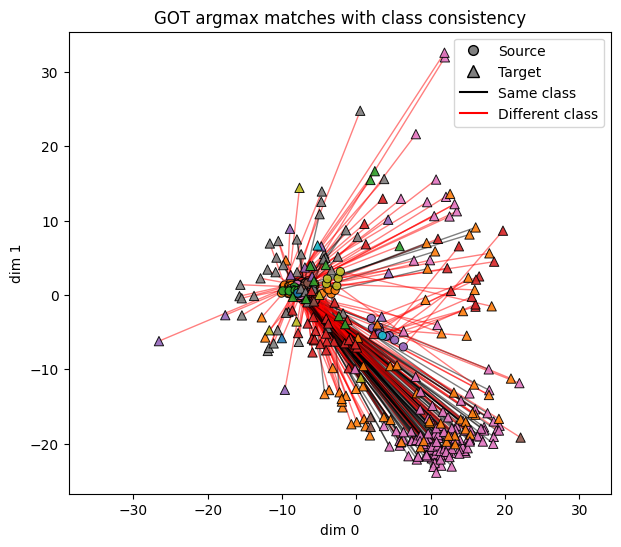

In [39]:
plot_got_best_matches_with_labels(mouseX, humanX, gw, mouse_labels, human_labels)

### OT within humans with shared cell type and tissue ontologies

In [5]:
human1, human2 =  match_cells_by_celltype_tissue(human_adatas[0], human_adatas[1], cell_number=100)

In [6]:
human1.obs['cell_type'].value_counts()

cell_type
naive thymus-derived CD8-positive, alpha-beta T cell    8
pulmonary alveolar type 2 cell                          8
endothelial cell of artery                              7
mesenchymal stem cell                                   7
hematopoietic stem cell                                 7
naive thymus-derived CD4-positive, alpha-beta T cell    6
non-classical monocyte                                  5
CD4-positive, alpha-beta thymocyte                      5
vein endothelial cell                                   4
thymic fibroblast type 1                                4
capillary endothelial cell                              3
B cell                                                  3
hematopoietic precursor cell                            3
respiratory tract goblet cell                           3
bronchial smooth muscle cell                            3
CD8-positive, alpha-beta T cell                         3
thymocyte                                               2
natu

In [7]:
num_cells = human1.obsm['X_pca'].shape[0]

In [8]:
human1_X = human1.obsm['X_pca']
human2_X = human2.obsm['X_pca']

In [9]:
human1_labels = human1.obs['shared_cell_type'].tolist()
human2_labels = human2.obs['shared_cell_type'].tolist()

In [16]:
gw_human = run_ot(human1_X, human2_X, num_cells, epsilon=0.1)

In [48]:
compute_mapping_acc(gw_human, human1_labels, human2_labels)

0.19

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([24, 15, 27, 97, 30, 91, 86, 58, 47, 32, 31, 99, 26, 43, 11, 18, 14,
        17, 22, 38, 39, 87, 83, 36, 70, 98, 53,  8, 62, 80,  3, 81, 90, 21,
        94, 45, 13, 16, 44, 92, 96,  4, 51, 89, 29, 35, 54, 68, 69, 48, 74,
        72, 20, 19, 61, 41, 60, 73,  5, 67, 46, 82, 65,  2, 25, 49, 10, 28,
        76, 75, 79,  9,  6,  7, 55, 66, 56, 85, 63, 23, 52, 50, 40, 78,  1,
        42, 12, 88, 57, 93, 95, 84, 71, 64, 77,  0, 37, 59, 34, 33]),
 array([0.00999956, 0.00999757, 0.00999872, 0.00998193, 0.00999979,
        0.00999862, 0.00999571, 0.00999998, 0.00999803, 0.00999923,
        0.00975927, 0.00988322, 0.00976592, 0.00999801, 0.00999855,
        0.01      , 0.00999977, 0.00999916, 0.00999951, 0.00999997,
        0.00999919, 0.00999907, 0.00999771, 0.00999181, 0.00999883,
        0.00999969, 0.00999257, 0.0099991 , 0.01      , 0.00999999,
  

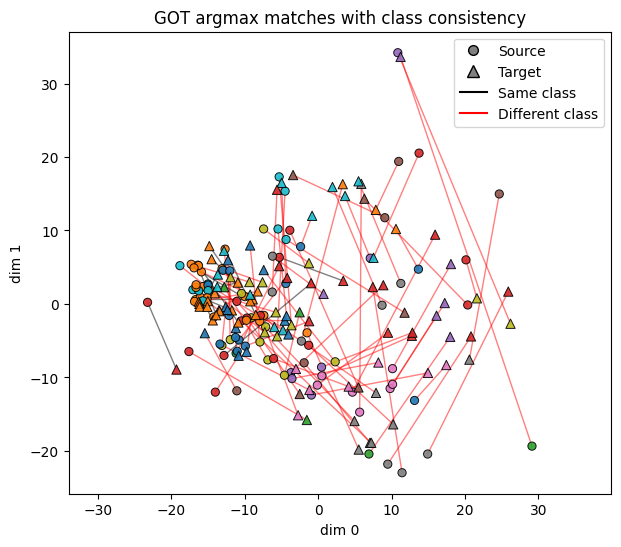

In [49]:
plot_got_best_matches_with_labels(human1_X, human2_X, gw_human, human1_labels, human2_labels)

### GOT with anchoring of singletons

In [10]:
def singleton_pair_indices(
    adata1: "ad.AnnData",
    adata2: "ad.AnnData",
    cell_type_key: str = "cell_type_ontology_term_id",
    tissue_key: str = "tissue_ontology_term_id",
) -> Tuple[List[int], List[int]]:
    """
    Given two AnnData objects (typically aligned outputs of match_max_cells_by_celltype_tissue),
    return two lists of integer positions for cells whose (cell_type, tissue) identity occurs
    exactly once *within that AnnData object*.

    Notes:
    - This does NOT assume adata1 and adata2 have the same singleton identities.
    - If you want "singleton in BOTH", filter using intersection of the returned positions.
    """
    def _singletons(a: ad.AnnData) -> List[int]:
        if cell_type_key not in a.obs or tissue_key not in a.obs:
            raise KeyError(f"Missing {cell_type_key!r} or {tissue_key!r} in .obs")

        ct = a.obs[cell_type_key].astype("string")
        tt = a.obs[tissue_key].astype("string")

        key = (ct.astype(str) + "|" + tt.astype(str)).to_numpy()
        counts = pd.Series(key).value_counts()

        # positions where that key occurs exactly once
        mask = np.array([counts[k] == 1 for k in key], dtype=bool)
        return np.flatnonzero(mask).tolist()

    return _singletons(adata1), _singletons(adata2)

In [11]:
anchors1, anchors2 = singleton_pair_indices(human1, human2)

In [12]:
gw_human_seeded = gw_seeded(human1_X, human2_X, num_cells, anchors1, anchors2, epsilon=0.1)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


KeyboardInterrupt: 

In [ ]:
compute_mapping_acc(gw_human_seeded, human1_labels, human2_labels)

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([52, 57, 27, 61,  4,  5, 83,  2,  8, 32, 41, 37, 48, 73, 14,  1, 43,
        17, 22, 25, 20, 24, 42, 36, 15, 96, 12, 87, 34,  9, 55, 81,  7, 18,
        21, 99, 13, 38, 64, 47, 40, 54, 51, 89, 58, 19, 65, 59,  3, 31, 50,
        72, 39, 53, 69, 97, 60, 80, 86,  0, 76, 82, 62, 93,  6, 16, 10, 28,
        92, 75, 79, 90, 63, 67, 74, 30, 33, 84, 70, 46, 88, 26, 66, 11, 23,
        85, 68, 77, 29, 94, 78, 91, 71, 49, 44, 95, 45, 35, 98, 56]),
 array([0.01      , 0.00999415, 0.00999537, 0.0099875 , 0.01      ,
        0.00999912, 0.00999854, 0.00999389, 0.00999794, 0.00999972,
        0.00999775, 0.00992822, 0.00998677, 0.0099982 , 0.00999911,
        0.00999965, 0.00999824, 0.01      , 0.00999873, 0.00999981,
        0.00999817, 0.00999875, 0.0099989 , 0.00999283, 0.00999898,
        0.00937524, 0.01      , 0.00999947, 0.01      , 0.01      ,
  

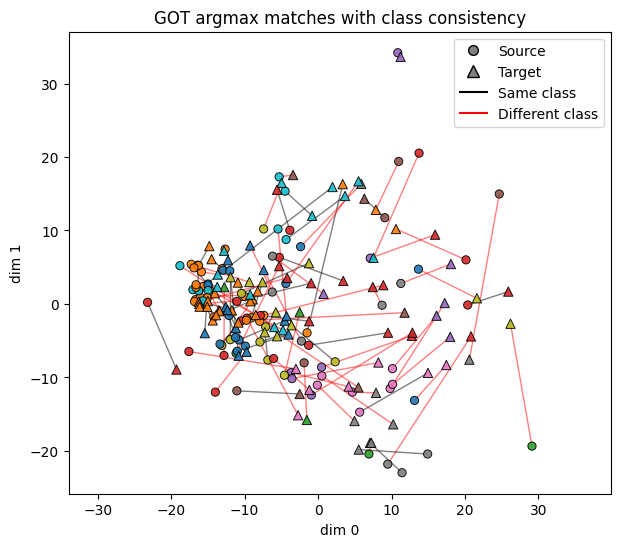

In [56]:
plot_got_best_matches_with_labels(human1_X, human2_X, gw_human_seeded, human1_labels, human2_labels)

In [58]:
### Retry with geodesic distances (no anchors)
gw_human_geodesic = run_ot(human1_X, human2_X, num_cells, epsilon=0.1, distance_method='geodesic', knn_k=3)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [59]:
compute_mapping_acc(gw_human_geodesic, human1_labels, human2_labels)

0.08

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([27, 65, 64,  7, 13, 72, 80, 97,  3, 59, 82, 67, 94, 81,  5, 25, 43,
        66, 37,  2, 11, 45, 14, 16,  8, 57, 84, 85, 49, 99, 95, 90, 61, 77,
        30, 88, 19, 24,  9, 73, 74, 75,  4, 69, 96, 93, 89, 24, 98, 50,  1,
        17, 33, 46, 28, 55, 71, 92, 39, 76, 29, 35, 52, 31, 91, 36, 34, 44,
        15, 26, 51, 32, 56, 68, 18, 23, 83, 47, 63, 54, 38, 42, 41, 58, 48,
        20, 70, 22, 16, 53, 62, 78, 86, 40,  6, 79,  0, 10, 87, 60]),
 array([0.00999877, 0.00981067, 0.00964061, 0.00602468, 0.00989988,
        0.00997991, 0.00999796, 0.00999977, 0.00969552, 0.00646441,
        0.00950824, 0.00870347, 0.00952675, 0.00996814, 0.00999471,
        0.00999894, 0.0099047 , 0.00987525, 0.00990827, 0.00999821,
        0.00999585, 0.00997349, 0.0099913 , 0.00380703, 0.00997853,
        0.00932664, 0.00996768, 0.00998686, 0.00999546, 0.0099621 ,
  

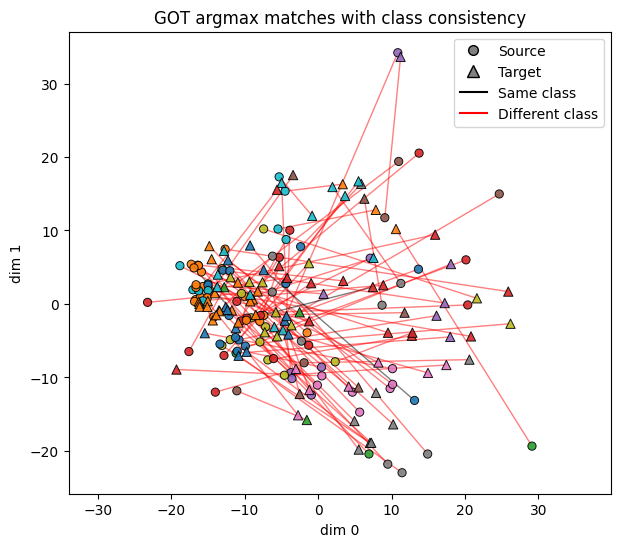

In [60]:
plot_got_best_matches_with_labels(human1_X, human2_X, gw_human_geodesic, human1_labels, human2_labels)

### Retry init anchored OT with geodesic distances

In [14]:
gw_human_seeded_geodesic = gw_seeded(human1_X, human2_X, num_cells, anchors1, anchors2, epsilon=0.1, distance_method='geodesic')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [15]:
compute_mapping_acc(gw_human_seeded_geodesic, human1_labels, human2_labels)

0.27

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>)

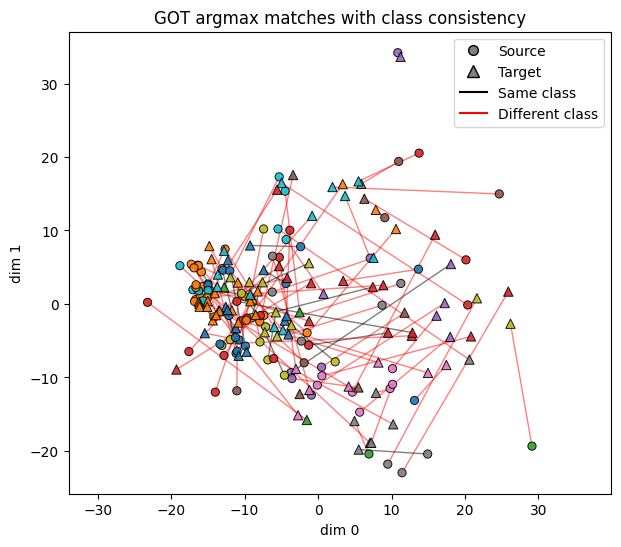

In [20]:
plot_got_best_matches_with_labels(human1_X, human2_X, gw_human_seeded_geodesic, human1_labels, human2_labels)

In [13]:
# Trying with more cells
human1, human2 =  match_cells_by_celltype_tissue(human_adatas[0], human_adatas[1], cell_number=500)

In [14]:
num_cells = human1.obsm['X_pca'].shape[0]

In [15]:
human1_X = human1.obsm['X_pca']
human2_X = human2.obsm['X_pca']

In [16]:
human1_labels = human1.obs['shared_cell_type'].tolist()
human2_labels = human2.obs['shared_cell_type'].tolist()

In [17]:
anchors1, anchors2 = singleton_pair_indices(human1, human2)

In [46]:
gw_human_seeded_500 = gw_seeded(human1_X, human2_X, num_cells, anchors1, anchors2, epsilon=0.1, distance_method='euclidean')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [47]:
compute_mapping_acc(gw_human_seeded_500, human1_labels, human2_labels)

0.476

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>)

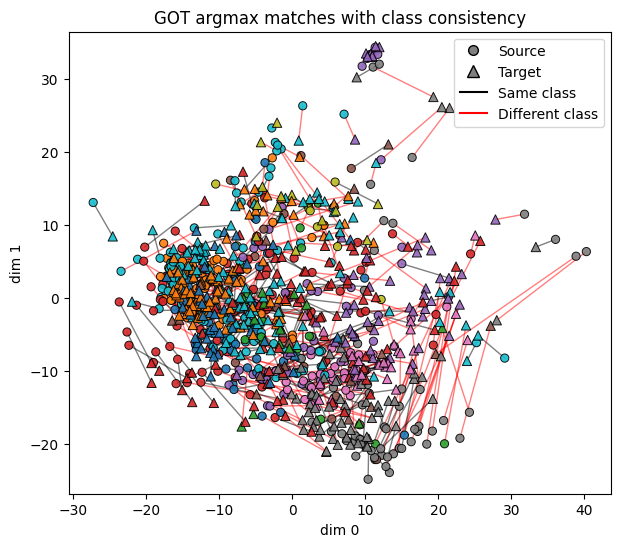

In [48]:
plot_got_best_matches_with_labels(human1_X, human2_X, gw_human_seeded_500, human1_labels, human2_labels)

### Redoing PCA before coupling

In [18]:
human1

AnnData object with n_obs × n_vars = 500 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'devel

In [19]:
sc.tl.pca(human1, n_comps=50, svd_solver="arpack")
sc.tl.pca(human2, n_comps=50, svd_solver="arpack")

In [20]:
num_cells = human1.obsm['X_pca'].shape[0]
human1_X = human1.obsm['X_pca']
human2_X = human2.obsm['X_pca']
human1_labels = human1.obs['shared_cell_type'].tolist()
human2_labels = human2.obs['shared_cell_type'].tolist()

In [21]:
gw_human = run_ot(human1_X, human2_X, num_cells, epsilon=0.1)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [22]:
compute_mapping_acc(gw_human, human1_labels, human2_labels)

0.4

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>)

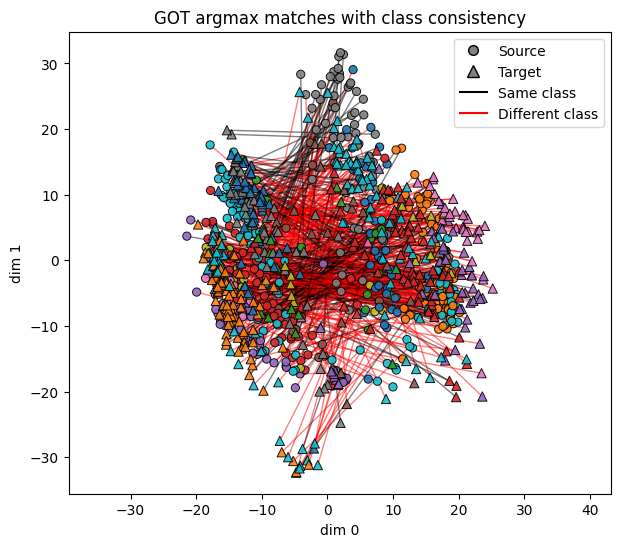

In [23]:
plot_got_best_matches_with_labels(human1_X, human2_X, gw_human, human1_labels, human2_labels)

In [16]:
def plot_gw_celltype_success_heatmap(
    gw,
    labels_source,
    labels_target=None,
    *,
    min_cells: int = 2,
    other_label: str = "other",
    cmap: str = "viridis",
    ax=None,
    title: str = "GW mass fraction by cell type",
    annotate: bool = False,
    fmt: str = ".2f",
):
    """
    Heatmap where rows = source cell types and cols = target cell types.
    Entry (i,j) = fraction of total mass leaving source type i that goes to target type j.

    - Cell types with < min_cells are grouped into `other_label` (on each side).
    - Row AND column order is by *source* cell-type counts (descending).
    - Axis tick labels include counts from the corresponding dataset:
        "B cell (123)"

    Parameters
    ----------
    gw : array-like (n_source, n_target)
        Transport plan / coupling.
    labels_source : array-like length n_source
        Source labels (e.g., adata_source.obs['shared_cell_type']).
    labels_target : array-like length n_target or None
        Target labels (e.g., adata_target.obs['shared_cell_type']). If None, uses labels_source.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    G = np.asarray(gw)
    ls = np.asarray(labels_source)
    lt = ls if labels_target is None else np.asarray(labels_target)

    if G.shape != (ls.shape[0], lt.shape[0]):
        raise ValueError(f"gw shape {G.shape} must match (len(labels_source), len(labels_target))")

    def _collapse(labels):
        s = pd.Series(labels, dtype="string")
        counts = s.value_counts(dropna=False)
        rare = set(counts[counts < min_cells].index.astype(str))
        out = s.astype(str).where(~s.astype(str).isin(rare), other_label)
        return out.to_numpy()

    ls2 = _collapse(ls)
    lt2 = _collapse(lt)

    # Counts AFTER collapsing
    src_counts = pd.Series(ls2).value_counts()
    tgt_counts = pd.Series(lt2).value_counts()

    # Order by SOURCE counts (descending). Put "other" last if present.
    ordered = [k for k in src_counts.index.tolist() if k != other_label]
    if other_label in src_counts.index:
        ordered.append(other_label)

    # Only keep types that actually appear on each side, but maintain source-count order
    row_types = [t for t in ordered if t in set(ls2)]
    col_types = [t for t in ordered if t in set(lt2)]
    # If target has types not in source (rare if you're using "shared_cell_type"), append them at end by target count
    extra_cols = [t for t in tgt_counts.index.tolist() if t not in set(col_types)]
    for t in extra_cols:
        if t == other_label and t in col_types:
            continue
        col_types.append(t)

    # indices by type
    row_idx = {t: np.flatnonzero(ls2 == t) for t in row_types}
    col_idx = {t: np.flatnonzero(lt2 == t) for t in col_types}

    # mass by (row_type, col_type)
    M = np.zeros((len(row_types), len(col_types)), dtype=float)
    for i, rt in enumerate(row_types):
        r = row_idx[rt]
        if r.size == 0:
            continue
        Gr = G[r, :]  # subset rows once
        for j, ct in enumerate(col_types):
            c = col_idx[ct]
            if c.size == 0:
                continue
            M[i, j] = Gr[:, c].sum()

    # row-normalize to get fractions of mass leaving each source type
    row_sums = M.sum(axis=1, keepdims=True)
    frac = np.divide(M, row_sums, out=np.zeros_like(M), where=row_sums > 0)

    # Axis tick labels with counts from each dataset (post-collapse)
    ytick = [f"{t} ({int(src_counts.get(t, 0))})" for t in row_types]
    xtick = [f"{t} ({int(tgt_counts.get(t, 0))})" for t in col_types]

    frac_df = pd.DataFrame(frac, index=row_types, columns=col_types)

    if ax is None:
        fig, ax = plt.subplots(figsize=(0.5 * len(col_types) + 4, 0.35 * len(row_types) + 3))
    else:
        fig = ax.figure

    im = ax.imshow(frac, aspect="auto", interpolation="nearest", cmap=cmap, vmin=0, vmax=1)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Fraction of mass from row type")

    ax.set_title(title)
    ax.set_xlabel("Target cell type")
    ax.set_ylabel("Source cell type")

    ax.set_xticks(np.arange(len(col_types)))
    ax.set_xticklabels(xtick, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(row_types)))
    ax.set_yticklabels(ytick)

    if annotate:
        for i in range(frac.shape[0]):
            for j in range(frac.shape[1]):
                ax.text(j, i, format(frac[i, j], fmt), ha="center", va="center", fontsize=8)

    ax.set_xlim(-0.5, len(col_types) - 0.5)
    ax.set_ylim(len(row_types) - 0.5, -0.5)

    return fig, ax, frac_df


(<Figure size 1450x1035 with 2 Axes>,
 <Axes: title={'center': 'GW mass fraction by cell type'}, xlabel='Target cell type', ylabel='Source cell type'>,
                          endothelial cell        T cell      monocyte  \
 endothelial cell             8.904479e-01  4.245587e-05  3.846490e-06   
 T cell                       6.232945e-31  4.279885e-01  1.057181e-34   
 monocyte                     3.568560e-02  1.786011e-02  8.029225e-01   
 pulmonary alveolar cell      2.081528e-02  1.677849e-20  5.227556e-44   
 fibroblast                   1.583727e-02  6.348210e-17  2.272727e-02   
 thymocyte                    3.769311e-21  8.405896e-01  2.089713e-05   
 HPSC                         9.844399e-09  4.999158e-02  1.508876e-01   
 mesenchymal stem cell        1.616905e-42  3.757214e-62  2.144515e-56   
 NK cell                      6.809213e-33  8.862921e-02  1.609952e-27   
 goblet cell                  2.332962e-02  1.199167e-09  5.699052e-16   
 smooth muscle cell           1.81

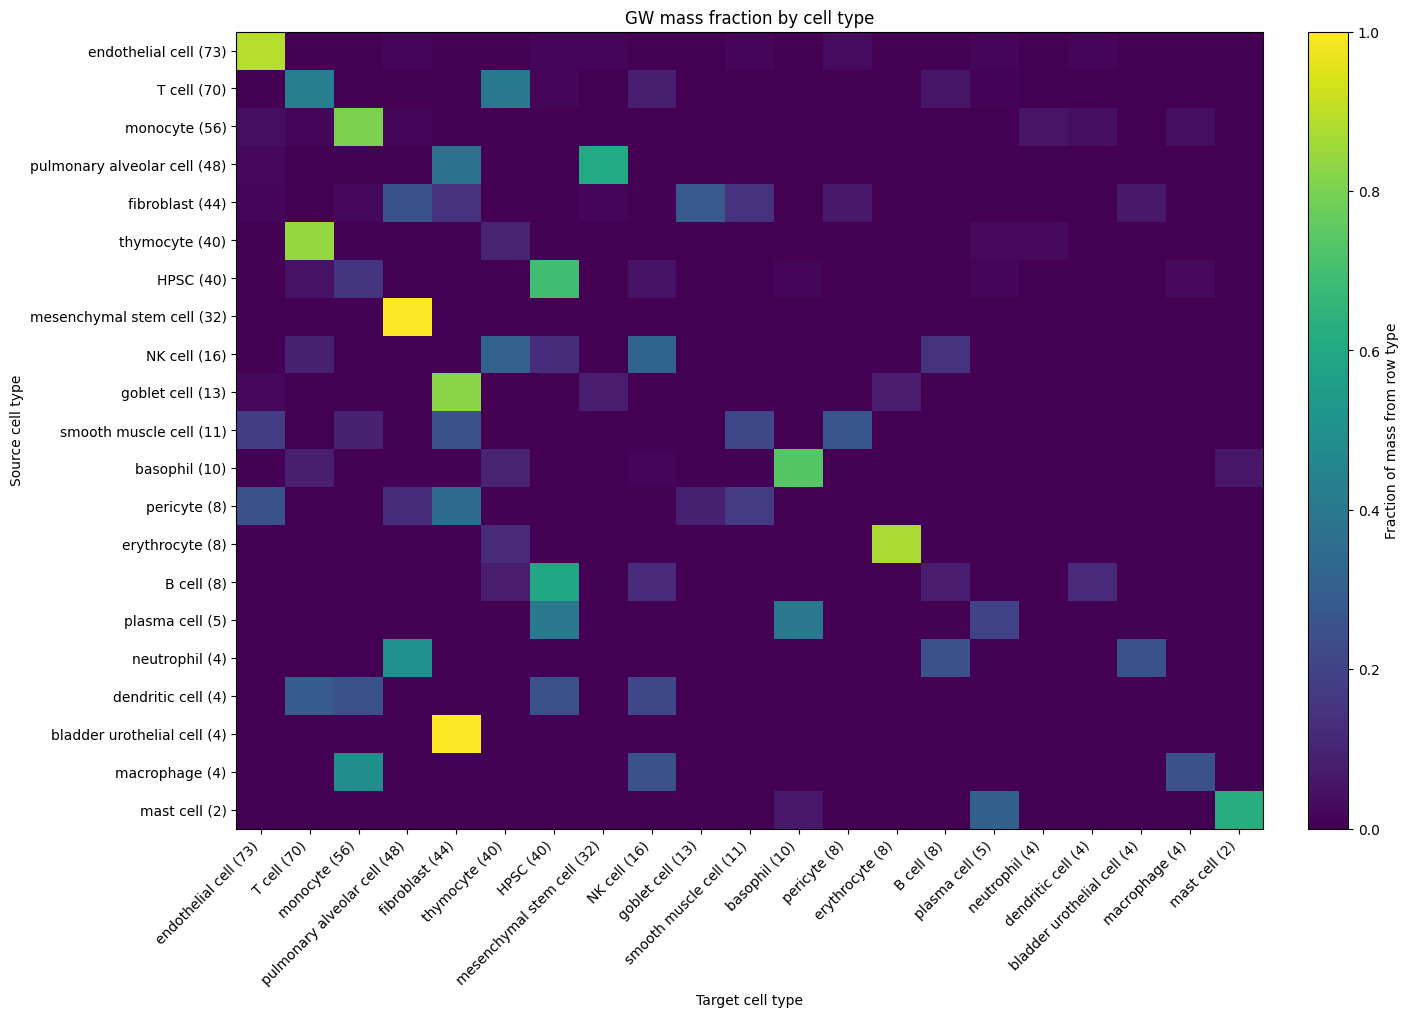

In [28]:
plot_gw_celltype_success_heatmap(gw_human, human1_labels, human2_labels)

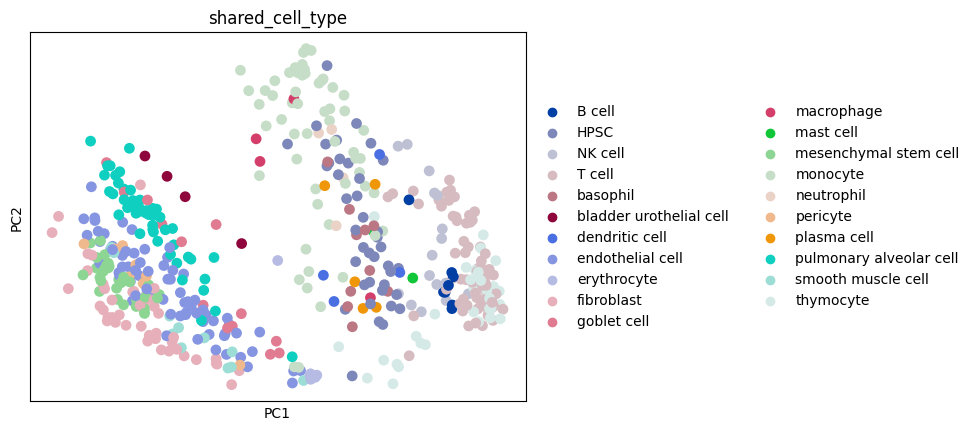

In [36]:
sc.pl.pca(human1, color='shared_cell_type')

In [38]:
human1

AnnData object with n_obs × n_vars = 500 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'devel

### Matching between the same human (easiest task)

In [8]:
human1a, human1b = split_adata_by_celltype_tissue(human_adatas[0], cell_number=100)

In [10]:
num_cells = human1a.obsm['X_pca'].shape[0]

In [11]:
sc.tl.pca(human1a, n_comps=50, svd_solver="arpack")
sc.tl.pca(human1b, n_comps=50, svd_solver="arpack")

In [31]:
human1a_X.shape

(100, 50)

In [13]:
human1a_X = human1a.obsm['X_pca']
human1b_X = human1b.obsm['X_pca']
human1a_labels = human1a.obs['shared_cell_type'].tolist()
human1b_labels = human1b.obs['shared_cell_type'].tolist()

In [14]:
gw_human_1ab = run_ot(human1a_X, human1b_X, num_cells, epsilon=0.1)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>)

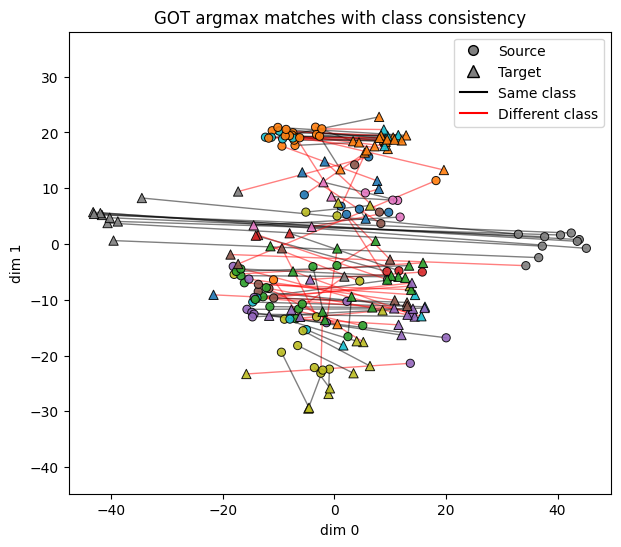

In [18]:
plot_got_best_matches_with_labels(human1a_X, human1b_X, gw_human_1ab, human1a_labels, human1b_labels)

(<Figure size 1200x860 with 2 Axes>,
 <Axes: title={'center': 'GW mass fraction by cell type'}, xlabel='Target cell type', ylabel='Source cell type'>,
                                 T cell  endothelial cell  \
 T cell                    6.315801e-01      5.263158e-02   
 endothelial cell          7.168730e-73      5.000001e-01   
 pulmonary alveolar cell   3.155229e-88      1.818182e-01   
 neutrophil               7.853841e-186     4.969910e-166   
 fibroblast               2.502841e-102      1.111111e-01   
 thymocyte                 7.999958e-01      2.636549e-70   
 mesenchymal stem cell     1.085374e-84      2.500000e-01   
 smooth muscle cell        3.707503e-96      6.779903e-34   
 monocyte                  7.099626e-69     1.491642e-105   
 HPSC                      5.000000e-01      3.914654e-93   
 erythrocyte              4.708935e-109      1.461799e-99   
 goblet cell              4.223740e-116      3.333333e-01   
 macrophage                3.333333e-01     5.089549e-10

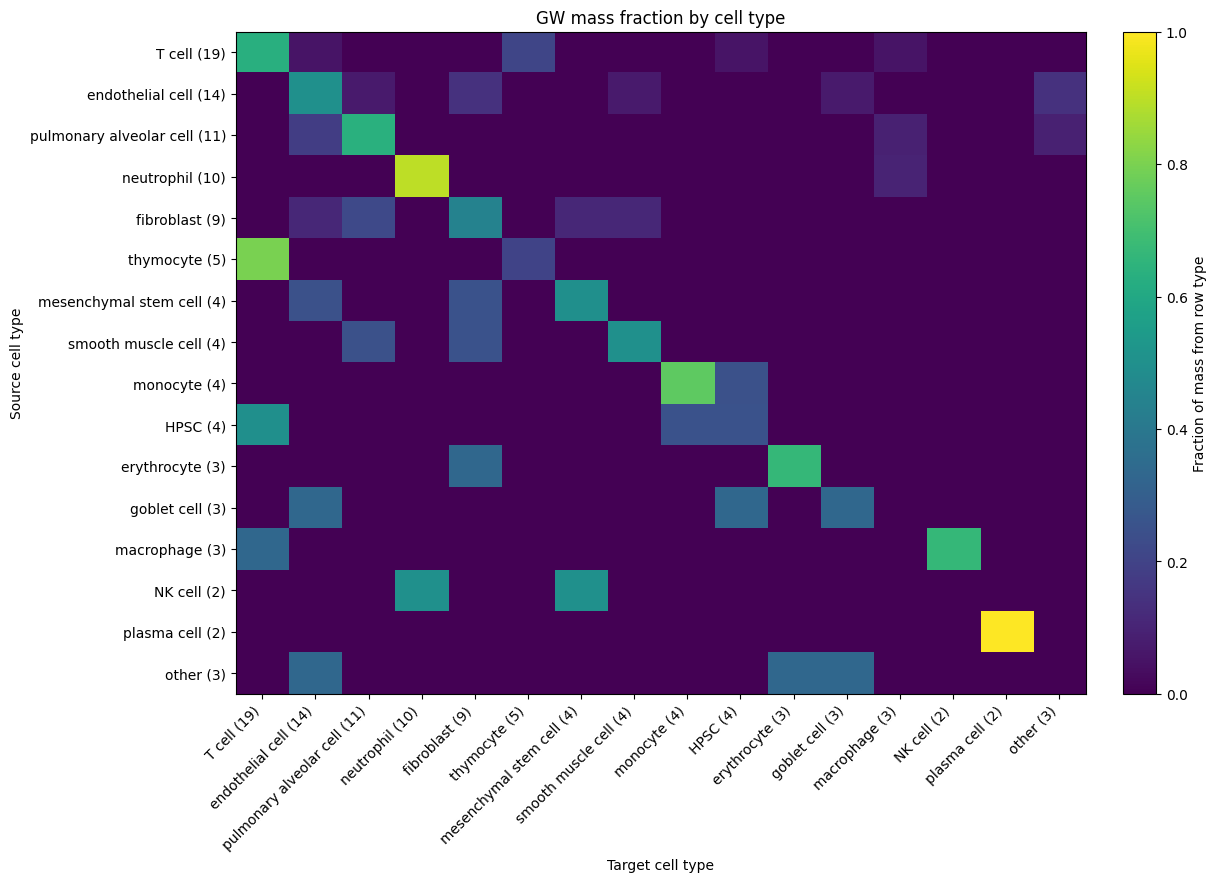

In [20]:
plot_gw_celltype_success_heatmap(gw_human_1ab, human1a_labels, human1b_labels)

(<Figure size 1200x860 with 2 Axes>,
 <Axes: title={'center': 'GW mass fraction by cell type'}, xlabel='Target cell type', ylabel='Source cell type'>,
                                 T cell  endothelial cell  \
 T cell                    6.315801e-01      5.263158e-02   
 endothelial cell          7.168730e-73      5.000001e-01   
 pulmonary alveolar cell   3.155229e-88      1.818182e-01   
 neutrophil               7.853841e-186     4.969910e-166   
 fibroblast               2.502841e-102      1.111111e-01   
 thymocyte                 7.999958e-01      2.636549e-70   
 mesenchymal stem cell     1.085374e-84      2.500000e-01   
 smooth muscle cell        3.707503e-96      6.779903e-34   
 monocyte                  7.099626e-69     1.491642e-105   
 HPSC                      5.000000e-01      3.914654e-93   
 erythrocyte              4.708935e-109      1.461799e-99   
 goblet cell              4.223740e-116      3.333333e-01   
 macrophage                3.333333e-01     5.089549e-10

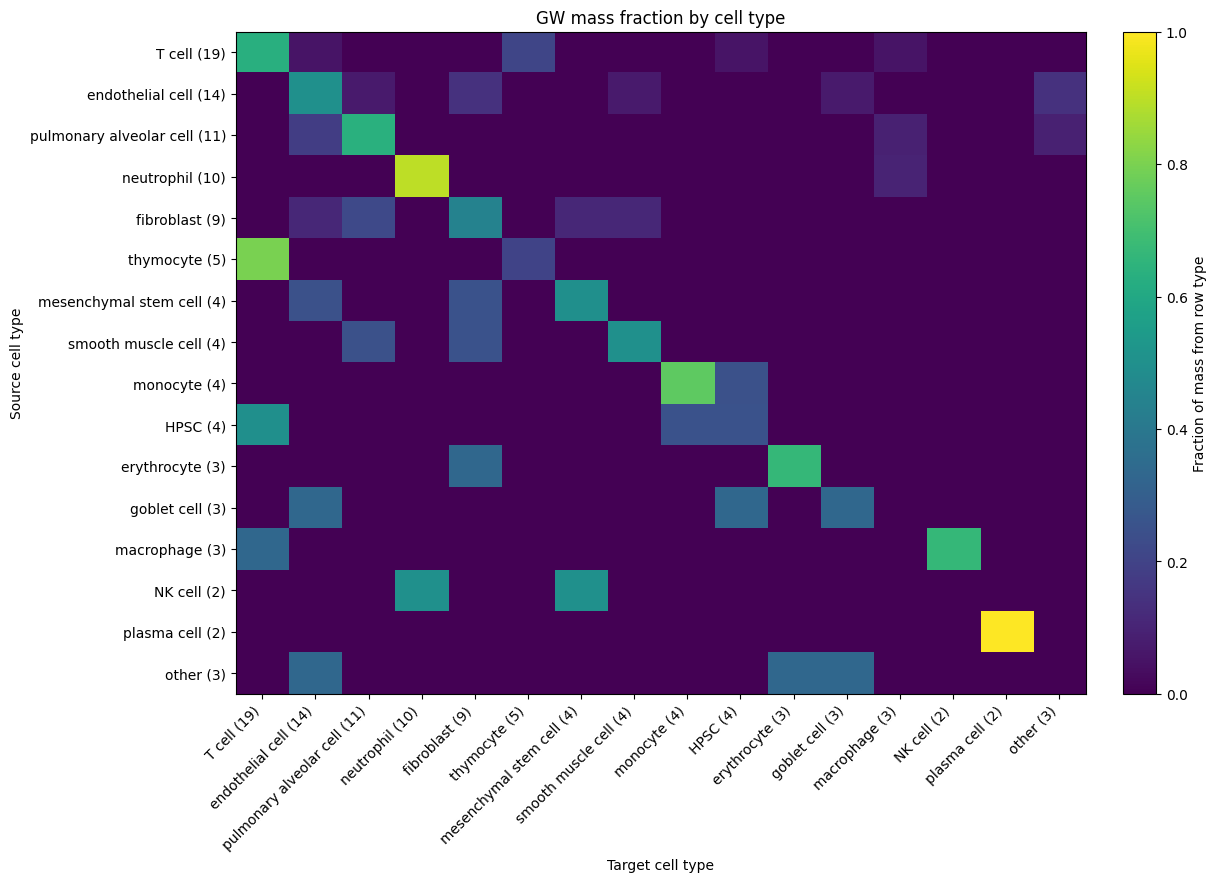

In [19]:
plot_gw_celltype_success_heatmap(gw_human_1ab, human1a_labels, human1b_labels)

In [21]:
def plot_ot_transport_by_celltype(
    transport,
    src_cell_types,
    tgt_cell_types,
    cmap="viridis",
    figsize=(8, 6),
):
    """
    Plot an OT transport plan heatmap grouped by cell type blocks.

    Parameters
    ----------
    transport : array-like (n_src, n_tgt)
        OT transport plan.
    src_cell_types : sequence of length n_src
        Cell-type labels for source cells.
    tgt_cell_types : sequence of length n_tgt
        Cell-type labels for target cells.
    """

    T = np.asarray(transport)

    src_ct = pd.Series(src_cell_types)
    tgt_ct = pd.Series(tgt_cell_types)

    # order cells by cell type (preserve first-seen order)
    src_order = src_ct.groupby(src_ct).indices
    tgt_order = tgt_ct.groupby(tgt_ct).indices

    src_idx = np.concatenate(list(src_order.values()))
    tgt_idx = np.concatenate(list(tgt_order.values()))

    M = T[np.ix_(src_idx, tgt_idx)]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(M, aspect="auto", cmap=cmap)
    plt.colorbar(im, ax=ax)

    # draw block boundaries
    for y in np.cumsum([len(v) for v in src_order.values()])[:-1]:
        ax.axhline(y - 0.5, color="white", lw=1)
    for x in np.cumsum([len(v) for v in tgt_order.values()])[:-1]:
        ax.axvline(x - 0.5, color="white", lw=1)

    # label blocks at centers
    ax.set_yticks(
        np.cumsum([0] + [len(v) for v in src_order.values()])[:-1]
        + np.array([len(v) for v in src_order.values()]) / 2
    )
    ax.set_yticklabels(list(src_order.keys()))

    ax.set_xticks(
        np.cumsum([0] + [len(v) for v in tgt_order.values()])[:-1]
        + np.array([len(v) for v in tgt_order.values()]) / 2
    )
    ax.set_xticklabels(list(tgt_order.keys()), rotation=90)

    ax.set_xlabel("target cells")
    ax.set_ylabel("source cells")
    ax.set_title("OT transport plan grouped by cell type")

    plt.tight_layout()
    return fig, ax


(<Figure size 1200x1000 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

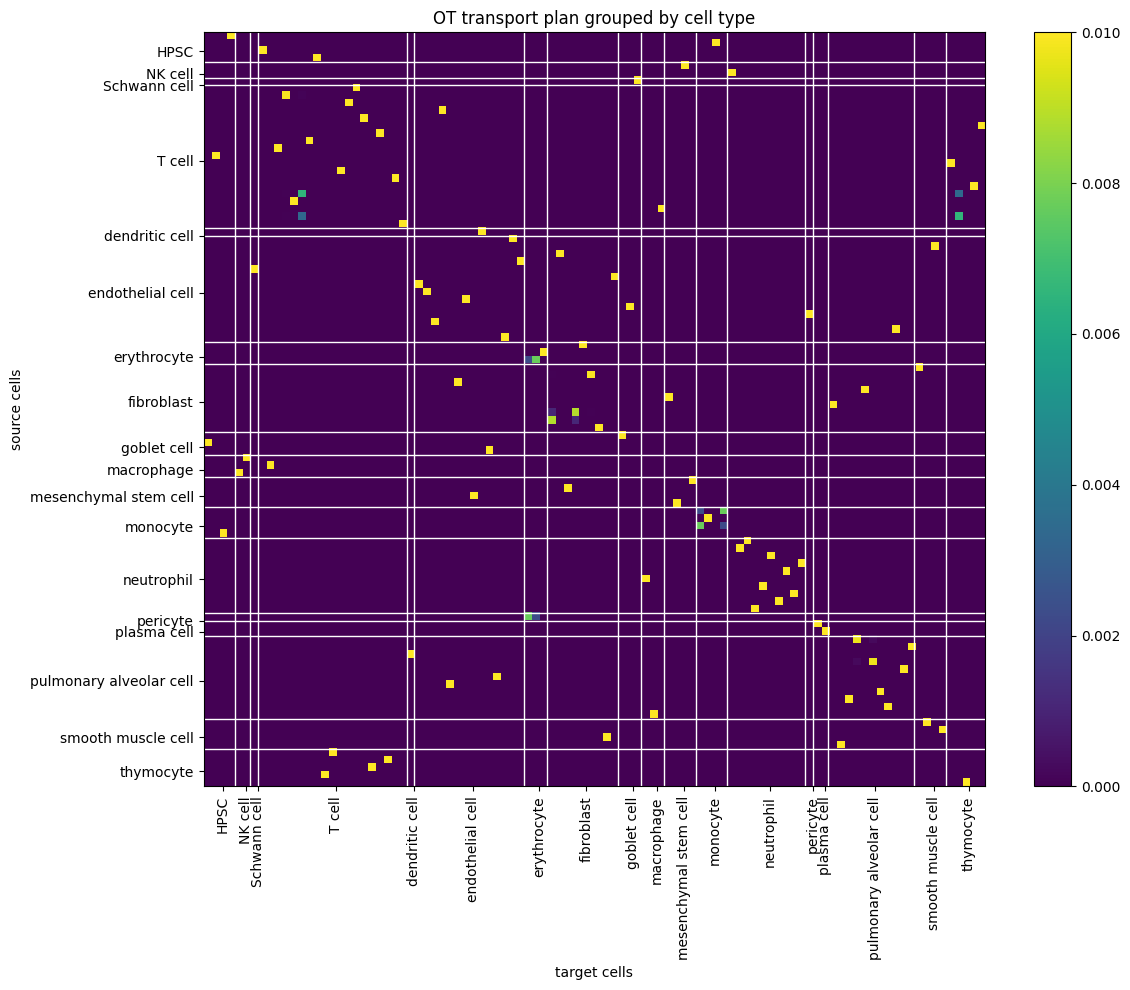

In [24]:
plot_ot_transport_by_celltype(gw_human_1ab, human1a_labels, human1b_labels, figsize=(12,10))

In [25]:
compute_mapping_acc(gw_human_1ab, human1a_labels, human1b_labels)

0.53

In [29]:
eps_arr=[1e-4, 1e-3, 1e-2, 0.1, 1]
acc_arr=[]
for eps in eps_arr:
    gw = run_ot(human1a_X, human1b_X, num_cells, epsilon=eps)
    acc = compute_mapping_acc(gw, human1a_labels, human1b_labels)
    acc_arr.append(acc)
    print(eps, acc)

0.0001 0.03
0.001 0.48
0.01 0.52
0.1 0.53
1 0.57


In [30]:
k_arr=[3, 5, 10, 20, 50]
acc_arr=[]
for k in k_arr:
    gw = run_ot(human1a_X, human1b_X, num_cells, epsilon=0.1, distance_method='geodesic', knn_k=k)
    acc = compute_mapping_acc(gw, human1a_labels, human1b_labels)
    acc_arr.append(acc)
    print(k, acc)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


3 0.1


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


5 0.09


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


...

20 0.29


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


50 0.38


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


100 0.57


k=100 is equivalent to using Euclidean distance, so there is no advantage to using geodesic distance.